# Clasificación de movimientos REHAB con KNN manual

**Actividad individual — rama `Andy`**

Este notebook explica y prueba una implementación manual de **K-Nearest Neighbors (KNN)**. El objetivo es predecir el movimiento realizado a partir de características extraídas de señales.


## 1. ¿Qué tipo de problema es?

La variable objetivo es `movimiento`. Sus valores (`000`, `001`, etc.) identifican categorías, no cantidades. Por eso se trata de un problema de **clasificación multiclase**.

- **Clasificación:** predice una categoría, como el movimiento `007`.
- **Regresión:** predice una cantidad continua, como una fuerza de 27.4 N.

Aunque las etiquetas estén escritas con dígitos, no existe una relación numérica de orden entre ellas: `010` no es “el doble” de `005`.

In [1]:
from pathlib import Path
import csv
from collections import Counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src" / "knn_manual.py").exists():
    raise FileNotFoundError("Ejecuta el notebook desde la carpeta entrega_andy.")

sys.path.insert(0, str(ROOT))
from src.knn_manual import (
    EstandarizadorManual,
    KNNManual,
    cargar_y_agrupar_csv,
    dividir_estratificado,
    exactitud,
    ejecutar_experimento,
    matriz_confusion,
)

RUTA_DATOS = ROOT / "data" / "df_final.csv"
print("Dataset:", RUTA_DATOS)
print("Existe:", RUTA_DATOS.exists())

Dataset: /home/andy/Documents/Codex/2026-09-01/instrucciones-entregable-implementaci-n-de-una/outputs/entrega_andy/data/df_final.csv
Existe: True


## 3. Estructura del dataset recibido

Cada fila original representa una **ventana** de una repetición. Las primeras columnas son identificadores:

- `movimiento`: clase que se desea predecir.
- `repeticion_id`: repetición de la que proviene la ventana.
- `ventana`: posición de la ventana dentro de la repetición.

Las demás columnas son características numéricas. Para cada señal se conservaron:

| Característica | Significado |
|---|---|
| `std` | Dispersión de la señal respecto a su promedio. |
| `median` | Valor central, resistente a valores extremos. |
| `min` | Menor valor observado. |
| `max` | Mayor valor observado. |
| `iqr` | Rango entre los percentiles 25 y 75. |
| `mad_diff` | Cambio absoluto promedio entre observaciones consecutivas. |

No se utilizan las características `mean`, `range`, `rms` ni `energy`, de acuerdo con la corrección recibida.

In [2]:
df = pd.read_csv(RUTA_DATOS, dtype={"movimiento": str, "repeticion_id": str})
columnas_id = ["movimiento", "repeticion_id", "ventana"]
columnas_features = [c for c in df.columns if c not in columnas_id]

resumen = pd.Series({
    "filas": len(df),
    "columnas_totales": len(df.columns),
    "características": len(columnas_features),
    "movimientos": df["movimiento"].nunique(),
    "repeticiones": df["repeticion_id"].nunique(),
    "datos_faltantes": int(df.isna().sum().sum()),
})
display(resumen.to_frame("resultado"))
display(df.head(3))

,resultado
filas,34056
columnas_totales,75
características,72
movimientos,15
repeticiones,4257
datos_faltantes,0


,movimiento,repeticion_id,ventana,pitch1_std,pitch1_median,pitch1_min,pitch1_max,pitch1_iqr,pitch1_mad_diff,yaw1_std,...,f5_min,f5_max,f5_iqr,f5_mad_diff,pitch3_std,pitch3_median,pitch3_min,pitch3_max,pitch3_iqr,pitch3_mad_diff
0,000,000_0001,1,27.407620,-14.465941,-49.403141,27.532859,54.811625,1.022145,6.225978,...,-9.145568,6.354432,9.825,0.259633,69.144078,43.791327,-95.283864,85.718660,135.985946,2.531138
1,000,000_0001,2,32.124926,28.154059,-42.124041,55.319659,58.130575,1.142213,6.924127,...,-5.945568,5.254432,1.000,0.141284,70.721517,-78.907298,-91.496040,102.666751,91.967748,2.549152
2,000,000_0001,3,19.543044,-31.069241,-48.141441,13.094959,37.844550,0.612022,5.851873,...,-6.945568,4.254432,3.275,0.311009,68.491422,79.377449,-81.726537,112.044924,113.431176,3.701181


,repeticiones
movimiento,
000,232
001,212
002,267
003,250
004,287
005,293
006,260
007,385
008,299


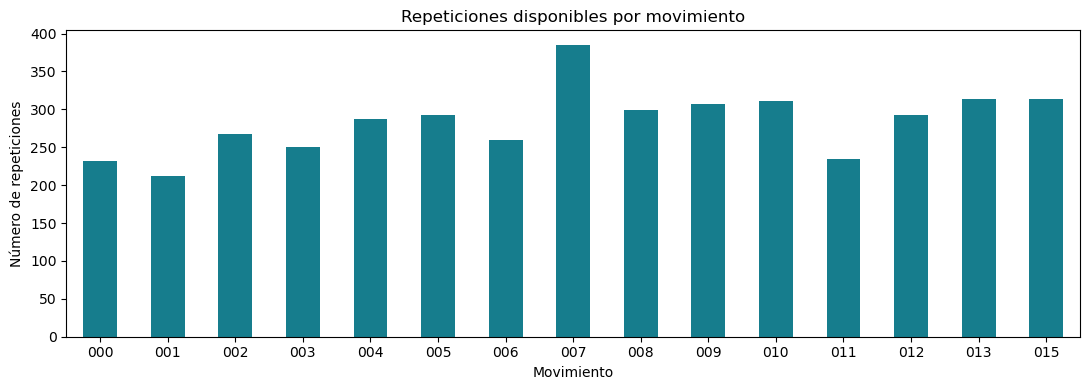

In [3]:
conteo_clases = df.groupby("movimiento")["repeticion_id"].nunique().sort_index()
display(conteo_clases.to_frame("repeticiones"))

ax = conteo_clases.plot(kind="bar", figsize=(11, 4), color="#167D8D")
ax.set_title("Repeticiones disponibles por movimiento")
ax.set_xlabel("Movimiento")
ax.set_ylabel("Número de repeticiones")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observación sobre la clase 014

El archivo recibido contiene 15 clases. Aparecen `000` a `013` y `015`; no existen filas con la clase `014`. El modelo no puede aprender ni predecir correctamente una clase que no esté presente en entrenamiento. Esto debe documentarse como una limitación del dataset.

## 4. Unidad de análisis y prevención de fuga de información

Cada `repeticion_id` contiene exactamente ocho ventanas relacionadas. Si se dividieran filas al azar, algunas ventanas de una repetición podrían quedar en entrenamiento y otras en prueba. El modelo recibiría información muy parecida a la que posteriormente se le pide predecir, generando una evaluación demasiado optimista.

Para evitarlo:

1. Se agrupan las ocho ventanas de cada repetición.
2. Cada característica se resume mediante su **mediana**.
3. La repetición completa queda únicamente en entrenamiento o únicamente en prueba.

La mediana empleada aquí resume las ventanas; no reincorpora la característica de señal `mean` que fue eliminada.

In [4]:
ventanas_por_repeticion = df.groupby("repeticion_id")["ventana"].nunique()
print("Mínimo de ventanas:", ventanas_por_repeticion.min())
print("Máximo de ventanas:", ventanas_por_repeticion.max())

dataset = cargar_y_agrupar_csv(RUTA_DATOS)
print("Forma original:", df.shape)
print("Forma usada por KNN:", dataset.x.shape)
print("Una fila por repetición:", len(dataset.ids) == df["repeticion_id"].nunique())

Mínimo de ventanas: 8
Máximo de ventanas: 8


Forma original: (34056, 75)
Forma usada por KNN: (4257, 72)
Una fila por repetición: True


## 5. División estratificada

Se destina aproximadamente 80 % de las repeticiones al entrenamiento y 20 % a la prueba. La división se hace por clase para mantener una proporción similar de movimientos en ambos conjuntos.

La semilla `2026` hace que la selección sea reproducible: ejecutar nuevamente el programa genera la misma partición.

In [5]:
train_idx, test_idx = dividir_estratificado(
    dataset.y, proporcion_prueba=0.20, semilla=2026
)

print("Entrenamiento:", len(train_idx))
print("Prueba:", len(test_idx))
print("Intersección de índices:", len(set(train_idx) & set(test_idx)))

comparacion = pd.DataFrame({
    "entrenamiento": pd.Series(Counter(dataset.y[train_idx])).sort_index(),
    "prueba": pd.Series(Counter(dataset.y[test_idx])).sort_index(),
}).fillna(0).astype(int)
display(comparacion)

Entrenamiento: 3406
Prueba: 851
Intersección de índices: 0


,entrenamiento,prueba
000,186,46
001,170,42
002,214,53
003,200,50
004,230,57
005,234,59
006,208,52
007,308,77
008,239,60
009,246,61


## 6. Normalización manual

KNN compara distancias. Una característica con números grandes podría dominar a otra solo por su escala. Para evitarlo se calcula, usando **exclusivamente entrenamiento**:

$$z = \frac{x - \mu}{\sigma}$$

donde $\mu$ es el promedio de entrenamiento y $\sigma$ su desviación estándar. Estos mismos parámetros se aplican después al conjunto de prueba.

Es importante no calcularlos con todo el dataset porque eso introduciría información de prueba en el entrenamiento.

In [6]:
escalador = EstandarizadorManual().ajustar(dataset.x[train_idx])
x_train = escalador.transformar(dataset.x[train_idx])
x_test = escalador.transformar(dataset.x[test_idx])

print("Promedio aproximado de las primeras 5 columnas normalizadas:")
print(np.round(np.mean(x_train, axis=0)[:5], 6))
print("Desviación estándar aproximada:")
print(np.round(np.std(x_train, axis=0)[:5], 6))

Promedio aproximado de las primeras 5 columnas normalizadas:
[-0. -0. -0. -0. -0.]
Desviación estándar aproximada:
[1. 1. 1. 1. 1.]


## 7. KNN implementado manualmente

Para una muestra nueva, KNN realiza estos pasos:

1. Calcula la distancia euclidiana respecto a cada muestra de entrenamiento.
2. Selecciona las `k` distancias menores.
3. Obtiene las etiquetas de esos vecinos.
4. Predice la etiqueta con más votos.

La distancia euclidiana entre dos muestras de $m$ características es:

$$d(x, y) = \sqrt{\sum_{j=1}^{m}(x_j-y_j)^2}$$

No es necesario calcular la raíz cuadrada para ordenar distancias: si una distancia al cuadrado es menor, su raíz también será menor. La implementación utiliza `k=5`, un número impar que disminuye la posibilidad de empates.

In [7]:
import inspect
print(inspect.getsource(KNNManual))

class KNNManual:
    """K vecinos más cercanos con distancia euclidiana y voto mayoritario."""

    def __init__(self, k: int = 5) -> None:
        if k < 1:
            raise ValueError("k debe ser un entero positivo.")
        self.k = k
        self.x_train: np.ndarray | None = None
        self.y_train: np.ndarray | None = None

    def ajustar(self, x: np.ndarray, y: np.ndarray) -> "KNNManual":
        if x.shape[0] != y.shape[0]:
            raise ValueError("X e y deben contener la misma cantidad de filas.")
        if self.k > x.shape[0]:
            raise ValueError("k no puede superar las muestras de entrenamiento.")
        self.x_train = np.asarray(x, dtype=float)
        self.y_train = np.asarray(y, dtype=str)
        return self

    def _predecir_una(self, muestra: np.ndarray) -> str:
        if self.x_train is None or self.y_train is None:
            raise RuntimeError("El modelo todavía no ha sido ajustado.")

        diferencias = self.x_train - muestra
        dista

## 8. Entrenamiento, predicciones y exactitud

En KNN, “entrenar” significa conservar las muestras y etiquetas de entrenamiento. La mayor parte del cálculo ocurre al predecir.

La exactitud se calcula manualmente como:

$$exactitud = \frac{predicciones\ correctas}{total\ de\ predicciones}$$

In [8]:
resultado = ejecutar_experimento(
    ruta_csv=RUTA_DATOS,
    k=5,
    proporcion_prueba=0.20,
    semilla=2026,
    ruta_predicciones=ROOT / "resultados" / "predicciones.csv",
    ruta_dataset_agrupado=ROOT / "data" / "dataset_modelo.csv",
)

print(f"Exactitud: {resultado['exactitud']:.2%}")
print("Predicciones correctas:", int(np.sum(resultado["y_test"] == resultado["predicciones"])))
print("Predicciones evaluadas:", len(resultado["y_test"]))

Exactitud: 87.31%
Predicciones correctas: 743
Predicciones evaluadas: 851


In [9]:
tabla_predicciones = pd.DataFrame({
    "repeticion_id": resultado["ids_prueba"],
    "movimiento_real": resultado["y_test"],
    "movimiento_predicho": resultado["predicciones"],
})
tabla_predicciones["correcta"] = (
    tabla_predicciones["movimiento_real"] == tabla_predicciones["movimiento_predicho"]
)
display(tabla_predicciones.head(15))

,repeticion_id,movimiento_real,movimiento_predicho,correcta
0,001_0137,001,010,False
1,012_0099,012,012,True
2,007_0219,007,007,True
3,015_0239,015,015,True
4,008_0281,008,008,True
5,006_0177,006,006,True
6,013_0047,013,013,True
7,013_0035,013,013,True
8,007_0142,007,007,True
9,009_0074,009,009,True


## 9. Matriz de confusión

La matriz permite observar no solo cuántas predicciones fueron correctas, sino qué movimientos se confunden entre sí:

- Las filas representan movimientos reales.
- Las columnas representan movimientos predichos.
- La diagonal contiene los aciertos.
- Los valores fuera de la diagonal son errores.

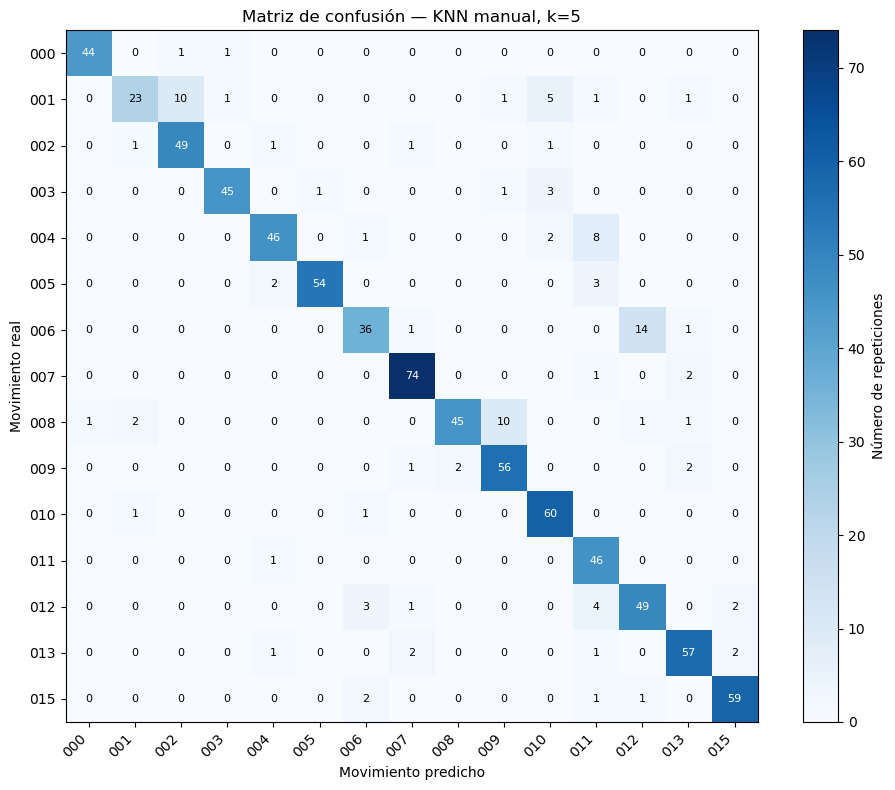

In [10]:
clases = resultado["clases"]
matriz = resultado["matriz_confusion"]

fig, ax = plt.subplots(figsize=(10, 8))
imagen = ax.imshow(matriz, cmap="Blues")
ax.set_xticks(range(len(clases)), clases, rotation=45, ha="right")
ax.set_yticks(range(len(clases)), clases)
ax.set_xlabel("Movimiento predicho")
ax.set_ylabel("Movimiento real")
ax.set_title("Matriz de confusión — KNN manual, k=5")

for i in range(len(clases)):
    for j in range(len(clases)):
        color = "white" if matriz[i, j] > matriz.max() * 0.55 else "black"
        ax.text(j, i, matriz[i, j], ha="center", va="center", color=color, fontsize=8)

fig.colorbar(imagen, ax=ax, label="Número de repeticiones")
plt.tight_layout()
plt.show()

## 10. Interpretación y conclusiones

El experimento aplica un KNN multiclase construido manualmente y evaluado sobre repeticiones que no participaron en el entrenamiento.

Aspectos importantes:

- El resultado es reproducible gracias a la semilla fija.
- Las repeticiones se mantienen completas para reducir fuga de información.
- La normalización se ajusta únicamente con entrenamiento.
- Las columnas de identificación no se usan como características.
- La clase `014` no puede evaluarse porque no aparece en el archivo recibido.
- Los códigos de movimiento deben sustituirse por nombres clínicos cuando se disponga de un diccionario de etiquetas.
- La exactitud describe este conjunto de prueba y no garantiza el mismo desempeño con pacientes o sesiones externas.



## Parte 2 — Comparación y selección de configuraciones

### 11. Modelos compatibles

El reto es una **clasificación multiclase** con 72 características numéricas. Los siguientes modelos clásicos son compatibles:

| Modelo | Compatibilidad | Consideración |
|---|---|---|
| KNN | Alta | Multiclase, no lineal y fácil de implementar manualmente. Requiere normalización. |
| Regresión logística multiclase | Alta | Interpretable, pero requiere optimización iterativa y puede producir fronteras lineales. |
| Árbol de decisión | Alta | No exige normalización, pero una implementación correcta requiere controlar divisiones y sobreajuste. |
| Naive Bayes gaussiano | Alta | Eficiente, pero supone independencia condicional y distribuciones gaussianas. |
| Regresión lineal | No adecuada | La salida es categórica, no una cantidad continua. |

Se conserva **KNN manual** porque cumple el requisito de no importar un algoritmo, admite directamente 15 clases y modela relaciones no lineales mediante proximidad. Las instrucciones permiten comparar diferentes configuraciones del mismo modelo; por ello se evaluarán siete valores de `k`.

### 12. Diseño experimental

Se crean tres conjuntos estratificados y separados por repetición:

- **60 % entrenamiento:** se utiliza para ajustar la normalización y conservar vecinos.
- **20 % validación:** permite comparar `k = 1, 3, 5, 7, 9, 11 y 15`.
- **20 % prueba:** permanece intacto durante la selección.

El criterio de selección, definido antes de consultar prueba, es:

1. Mayor F1 macro en validación.
2. Si existe empate, mayor exactitud.
3. Si continúa el empate, menor `k`.

F1 macro asigna el mismo peso a cada movimiento, aunque sus cantidades de repeticiones sean distintas. Después de seleccionar `k`, entrenamiento y validación se unen para formar el modelo final; prueba se utiliza una sola vez.

In [11]:
from src.comparar_configuraciones import comparar

comparativa = comparar(
    ruta_csv=RUTA_DATOS,
    valores_k=(1, 3, 5, 7, 9, 11, 15),
    semilla=2026,
    directorio_resultados=ROOT / "resultados",
)

tabla_comparacion = pd.DataFrame(comparativa["comparacion"])
display(tabla_comparacion.style.format({
    "exactitud": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "f1_macro": "{:.4f}",
    "segundos": "{:.3f}",
}))
print("Configuración seleccionada: k =", comparativa["mejor_k"])

,k,exactitud,precision_macro,recall_macro,f1_macro,segundos
0,1,0.9271,0.9298,0.9231,0.9234,0.164
1,3,0.8884,0.8876,0.8831,0.8831,0.175
2,5,0.8625,0.8678,0.8572,0.8602,0.180
3,7,0.8484,0.8555,0.8424,0.8457,0.180
4,9,0.8555,0.8600,0.8491,0.8519,0.181
5,11,0.8437,0.8484,0.8370,0.8399,0.178
6,15,0.8261,0.8310,0.8193,0.8222,0.181


Configuración seleccionada: k = 1


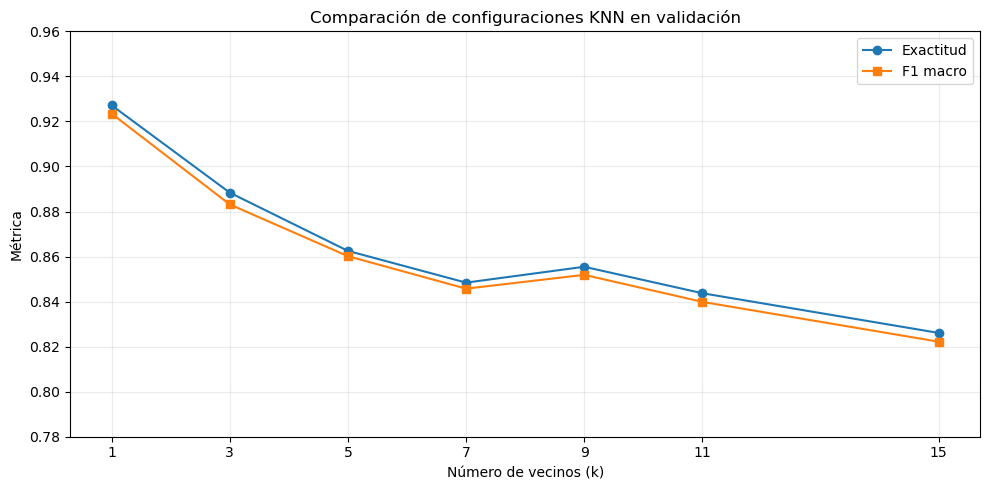

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tabla_comparacion["k"], tabla_comparacion["exactitud"], marker="o", label="Exactitud")
ax.plot(tabla_comparacion["k"], tabla_comparacion["f1_macro"], marker="s", label="F1 macro")
ax.set_title("Comparación de configuraciones KNN en validación")
ax.set_xlabel("Número de vecinos (k)")
ax.set_ylabel("Métrica")
ax.set_xticks(tabla_comparacion["k"])
ax.set_ylim(0.78, 0.96)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### 13. Decisión

Se selecciona `k=1` porque alcanza el mayor F1 macro (**0.9234**) y la mayor exactitud (**0.9271**) en validación. Los resultados disminuyen conforme crece `k`, lo que indica que incluir vecinos más alejados mezcla movimientos distintos y suaviza demasiado las fronteras entre clases.

Esta decisión se toma exclusivamente con validación. No se escoge `k` usando la exactitud de prueba.

,prueba final
exactitud,0.954172
precision_macro,0.956118
recall_macro,0.953775
f1_macro,0.952640


Entrenamiento inicial: 2555
Validación: 851
Desarrollo final (entrenamiento + validación): 3406
Prueba final: 851


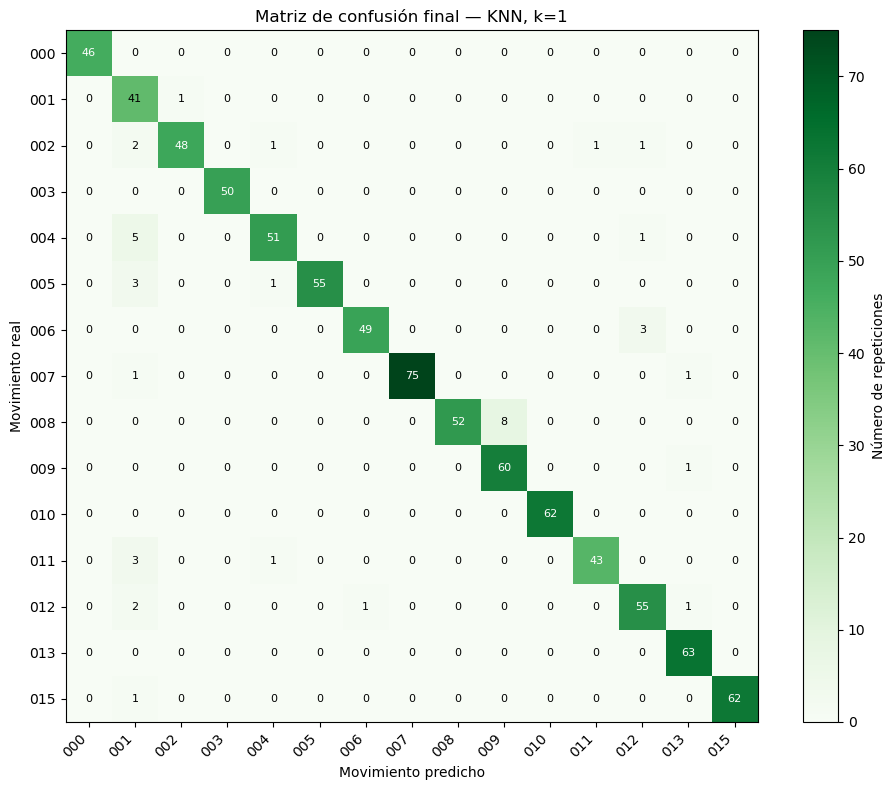

In [13]:
metricas_finales = pd.Series(comparativa["metricas_test"], name="prueba final")
display(metricas_finales.to_frame())

print("Entrenamiento inicial:", len(comparativa["train_idx"]))
print("Validación:", len(comparativa["val_idx"]))
print("Desarrollo final (entrenamiento + validación):", len(comparativa["train_idx"]) + len(comparativa["val_idx"]))
print("Prueba final:", len(comparativa["test_idx"]))

matriz_final = comparativa["matriz_confusion"]
clases_finales = comparativa["clases"]
fig, ax = plt.subplots(figsize=(10, 8))
imagen = ax.imshow(matriz_final, cmap="Greens")
ax.set_xticks(range(len(clases_finales)), clases_finales, rotation=45, ha="right")
ax.set_yticks(range(len(clases_finales)), clases_finales)
ax.set_xlabel("Movimiento predicho")
ax.set_ylabel("Movimiento real")
ax.set_title(f"Matriz de confusión final — KNN, k={comparativa['mejor_k']}")
for i in range(len(clases_finales)):
    for j in range(len(clases_finales)):
        color = "white" if matriz_final[i, j] > matriz_final.max() * 0.55 else "black"
        ax.text(j, i, matriz_final[i, j], ha="center", va="center", color=color, fontsize=8)
fig.colorbar(imagen, ax=ax, label="Número de repeticiones")
plt.tight_layout()
plt.show()

### 14. Resultado final de la segunda etapa

El modelo final se entrenó con 3,406 repeticiones de desarrollo y se evaluó sobre 851 repeticiones de prueba que no participaron en la selección:

- **Exactitud:** 0.9542 (95.42 %).
- **Precisión macro:** 0.9561.
- **Recall macro:** 0.9538.
- **F1 macro:** 0.9526.

La configuración seleccionada es KNN manual con `k=1`, normalización z-score y división por repetición. Esta configuración supera al KNN inicial con `k=5`, pero la comparación metodológicamente válida es la realizada sobre validación. El conjunto de prueba solamente proporciona la estimación final del desempeño esperado.